### Graphing Basis Assumption
This file pulls the previous minute of prices for spot and linear perps and graphs them

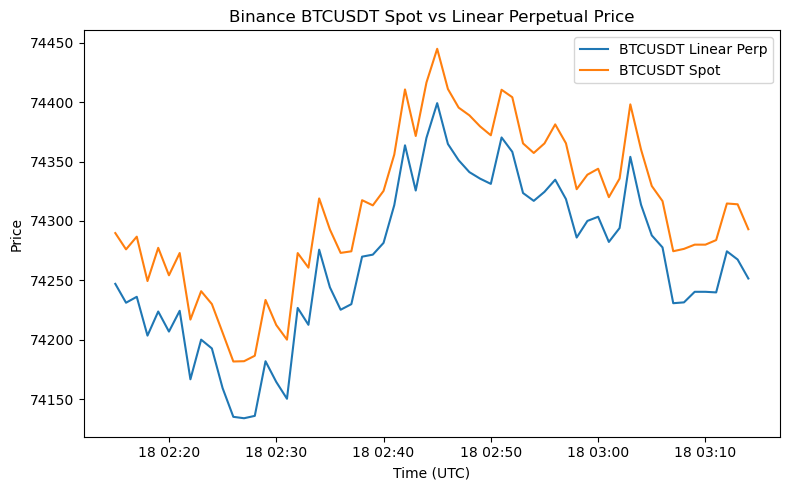

In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

SPOT_URL = "https://api.binance.com/api/v3/klines"
FUT_URL = "https://fapi.binance.com/fapi/v1/klines"

SYMBOL = "BTCUSDT"
INTERVAL = "1m"
LIMIT = 60  # last hour


def get_klines(url: str, symbol: str, interval: str, limit: int) -> pd.DataFrame:
    params = {
        "symbol": symbol,
        "interval": interval,
        "limit": limit,
    }
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    data = r.json()

    df = pd.DataFrame(data, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "num_trades",
        "taker_buy_base", "taker_buy_quote", "ignore"
    ])

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    return df[["open_time", "close"]].copy()


# Pull data
spot = get_klines(SPOT_URL, SYMBOL, INTERVAL, LIMIT)
perp = get_klines(FUT_URL, SYMBOL, INTERVAL, LIMIT)

# Merge on timestamp
df = spot.merge(
    perp,
    on="open_time",
    how="inner",
    suffixes=("_spot", "_perp")
)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(df["open_time"], df["close_perp"], label="BTCUSDT Linear Perp")
plt.plot(df["open_time"], df["close_spot"], label="BTCUSDT Spot")

plt.xlabel("Time (UTC)")
plt.ylabel("Price")
plt.title("Binance BTCUSDT Spot vs Linear Perpetual Price")
plt.legend()
plt.tight_layout()
plt.show()